# CUADERNO JUPYTER UNIFICADO: Práctica 1 – Metaheurísticas (Curso 2025/2026)
## Algoritmo 2: Hill Climbing (HC)

## 1. Introducción

El objetivo de esta práctica es segmentar una serie temporal en *k* segmentos, ajustando en cada uno de ellos una regresión lineal independiente. La calidad de una segmentación se evalúa mediante el **RMSE medio** de todos los segmentos, que actúa como función objetivo a minimizar.

En este cuaderno se implementa el algoritmo **Hill Climbing (HC)**, un método de búsqueda local que mejora la solución inicial explorando su vecindario. HC se utilizará para comparar su rendimiento con Random Search (RS) y Simulated Annealing (SA).

Hill Climbing sigue una estrategia simple pero más informada que RS:
- Parte de una segmentación inicial generada aleatoriamente.  
- Genera soluciones vecinas modificando ligeramente los puntos de corte.  
- Evalúa cada vecino mediante el RMSE medio.  
- Se desplaza al mejor vecino siempre que suponga una mejora.

A diferencia de RS, HC **sí explota la estructura del problema**, ya que utiliza información local para guiar la búsqueda. Esto suele permitirle obtener mejores soluciones y hacerlo en menos tiempo. Sin embargo, puede quedar atrapado en óptimos locales, lo que justifica la necesidad de compararlo con métodos más robustos como Simulated Annealing.

## 2. Importación de librerías

En esta sección se importan las librerías necesarias para:

- Cálculo numérico (`numpy`)
- Visualización (`matplotlib`)
- Ajuste de regresiones lineales (`sklearn`)
- Gestión de datos (`pandas`)
- Medición del error (`mean_squared_error`)
- Generación de números aleatorios y medición de tiempos

Estas herramientas permiten implementar y evaluar el algoritmo Hill Climbing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import pandas as pd
from tabulate import tabulate
import random
import time

## 3. Carga de series temporales

Se define una función auxiliar para leer los archivos de datos que contienen las series temporales TS1–TS4.  
Cada archivo contiene una lista de valores numéricos entre corchetes, por lo que es necesario limpiarlos antes de convertirlos a `float`.

Posteriormente, se cargan las cuatro series y se asocian con sus valores de *k* correspondientes:

- TS1 → k = 9  
- TS2 → k = 10  
- TS3 → k = 20  
- TS4 → k = 50  

Estas series serán utilizadas en los experimentos posteriores.

In [2]:
def read_serie(path):
    with open(path, "r") as f:
        contenido = f.read().replace("[", "").replace("]", "").split()
    return [float(x) for x in contenido]

files = ["../datos/TS1", "../datos/TS2", "../datos/TS3", "../datos/TS4"]
series = [read_serie(f) for f in files]
k_values = [9, 10, 20, 50]

print("Series cargadas correctamente")

Series cargadas correctamente


## 4. Regresión lineal por segmentos

El algoritmo Hill Climbing necesita evaluar la calidad de cada segmentación mediante el RMSE.  
Para ello se implementan funciones que permiten ajustar una regresión lineal a cada segmento.

### `estimate_coef(x, y)`
Calcula los coeficientes de la recta (pendiente y ordenada en el origen) usando fórmulas estadísticas básicas.

### `estimate_all_coef(temp, points)`
Calcula los coeficientes de todos los segmentos definidos por los puntos de corte.

### `estimate_all_points(coef, points, temp_size)`
Reconstruye la serie estimada completa a partir de los coeficientes de cada segmento.

Estas funciones permiten evaluar la calidad de una segmentación.

In [3]:
def estimate_coef(x, y):
    x = np.array(x)
    y = np.array(y)
    n = np.size(x)

    if n == 0:
        return (0.0, 0.0)

    m_x = np.mean(x)
    m_y = np.mean(y)

    SS_xy = np.sum(y * x) - n * m_y * m_x
    SS_xx = np.sum(x * x) - n * m_x * m_x

    if abs(SS_xx) < 1e-8:
        b_0 = 0.0
        b_1 = m_y
    else:
        b_0 = SS_xy / SS_xx
        b_1 = m_y - b_0 * m_x

    return (float(b_0), float(b_1))


def estimate_all_coef(temp, points):
    coef = []
    start = 0

    pts = points.copy()
    pts.append(len(temp))

    for point in pts:
        b_0, b_1 = estimate_coef(range(start, point), temp[start:point])
        coef.append((b_0, b_1))
        start = point

    return coef


def estimate_point(coef, i):
    return i * coef[0] + coef[1]

def estimate_all_points(coef, points, temp_size):
    estimated = []
    start = 0

    pts = points.copy()
    pts.append(temp_size)

    for pos, point in enumerate(pts):
        for i in range(start, point):
            estimated.append(estimate_point(coef[pos], i))
        start = point

    return estimated

## 5. Generación de puntos de corte aleatorios

Para inicializar Hill Climbing se necesita una solución inicial.  
La función `randomPoints` genera un conjunto de puntos de corte aleatorios sin repetición y ordenados, garantizando que los segmentos sean válidos.

In [4]:
def randomPoints(longitud_serie, n_cortes):
    b = []
    while n_cortes > 0:
        r = random.randint(1, longitud_serie - 1)
        if r not in b:
            b.append(r)
            n_cortes -= 1
    b.sort()
    return b

## 6. Cálculo del RMSE por segmentos

Para evaluar la calidad de una segmentación se utiliza el **RMSE medio** de todos los segmentos.

### `RMSE(y_real, y_pred)`
Calcula el error cuadrático medio entre valores reales y estimados.

### `mean_rmse(serie, points)`
Calcula el RMSE medio de todos los segmentos definidos por los puntos de corte.

Este valor es la función objetivo que Hill Climbing intenta minimizar.


In [5]:
def RMSE(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    return np.sqrt(mse)


def mean_rmse(serie, points):
    rmse_acc = 0.0
    start = 0
    coef = estimate_all_coef(serie, points.copy())
    estimated = estimate_all_points(coef, points.copy(), len(serie))
    pts = points.copy()
    pts.append(len(serie))

    for point in pts:
        rmse_acc += RMSE(serie[start:point], estimated[start:point])
        start = point

    return rmse_acc / len(pts)

# 7. Implementación del algoritmo Hill Climbing (HC)

Hill Climbing es un algoritmo de búsqueda local que:

1. Parte de una solución inicial aleatoria.  
2. Genera su vecindario modificando ligeramente los puntos de corte.  
3. Evalúa cada vecino mediante el RMSE.  
4. Se mueve al mejor vecino si mejora la solución actual.  
5. Repite el proceso hasta que no se encuentran mejoras.

HC explota la estructura del problema y suele obtener mejores resultados que Random Search, aunque puede quedar atrapado en óptimos locales.


## 7.1 Generación del vecindario en Hill Climbing

Para aplicar Hill Climbing es necesario definir qué consideramos un vecino de una solución.

Una solución está formada por un conjunto ordenado de puntos de corte:


$$ 
\text{solución} = [p_1, p_2, \dots, p_k]
$$




Cada vecino se genera modificando uno de los puntos de corte en ±1 posición (o ±1% del tamaño de la serie), respetando:

- Que ningún punto sea 0  
- Que ningún punto sea igual a la longitud total  
- Que los puntos estén estrictamente ordenados  
- Que no existan duplicados  
- Que no aparezcan segmentos vacíos  

Esto garantiza que todos los vecinos representan segmentaciones válidas.

In [6]:
def search_neighbour(serie, n):
    """
    Genera todos los vecinos válidos moviendo un punto ±1.
    Filtra duplicados, desordenados y puntos fuera de rango.
    """
    vecinos = []

    for i, point in enumerate(serie):
        # Mover + 1% del tamaño de la serie
        v1 = serie.copy()
        v1[i] = point + int(n / 50)
        vecinos.append(v1)

        # Mover - 1% del tamaño de la serie
        v2 = serie.copy()
        v2[i] = point - int(n / 50)
        vecinos.append(v2)

    validos = []

    for vect in vecinos:
        if vect[0] <= 0:
            continue
        if vect[-1] >= n:
            continue
        if len(set(vect)) != len(vect):
            continue
        if vect != sorted(vect):
            continue

        validos.append(vect)

    return validos

## 7.2 Implementación del algoritmo Hill Climbing

La función `hc` implementa el proceso completo:

- Genera una solución inicial aleatoria  
- Calcula su RMSE  
- Genera todos los vecinos válidos  
- Selecciona el mejor vecino  
- Si mejora, actualiza la solución  
- Si no mejora, el algoritmo se detiene  

La función devuelve:
- La mejor solución encontrada  
- Su RMSE  
- El tiempo total de ejecución  
- La evolución del RMSE durante la búsqueda  


In [7]:
def hc(serie, k):
    startTime = time.time()

    solucion = randomPoints(len(serie), k)
    rmse = mean_rmse(serie, solucion)
    mejor_vecino = []
    evolution=[]
    while mejor_vecino is not None:
        vecinos = search_neighbour(solucion, len(serie))

        mejor_vecino = None 
        mejor_rmse = rmse

        for v in vecinos:
            current = mean_rmse(serie, v)
            if current < mejor_rmse:
                mejor_rmse = current
                mejor_vecino = v

        if mejor_vecino is not None:
            solucion = mejor_vecino
            rmse = mejor_rmse

        evolution.append({"rmse":rmse,"points":solucion})


    endTime = time.time()
    return {"rmse": rmse, "points": solucion}, endTime - startTime, evolution


# 8. Ejecución del experimento completo

Para evaluar el rendimiento del algoritmo, se ejecuta Hill Climbing:

- Sobre las cuatro series temporales  
- Repitiendo el experimento 20 veces por serie  

En cada repetición se almacena:

- El RMSE final  
- Los puntos de corte óptimos  
- El tiempo de ejecución  

Estos datos se utilizarán posteriormente para generar gráficas y métricas comparativas.


In [8]:
def ejecutar_HC(series, k_values, repeticiones=20):
    resultados = []

    print("\n=== Ejecutando experimento Hill Climbing ===")

    for idx, serie in enumerate(series):
        k = k_values[idx]
        print(f"\nProcesando TS{idx + 1} (k={k})...")

        rep_result = []
        for rep in range(repeticiones):
            sol, tiempo, _= hc(serie, k)

            rep_result.append(
                {"rmse": sol["rmse"], "points": sol["points"], "tiempo": tiempo}
            )
            print(f"Repetición {rep + 1}/{repeticiones} completada")

        resultados.append(rep_result)

    print("\n=== Experimento finalizado ===")
    return resultados


In [14]:
resultados_HC = ejecutar_HC(series, k_values, repeticiones=20)


=== Ejecutando experimento Hill Climbing ===

Procesando TS1 (k=9)...
Repetición 1/20 completada
Repetición 2/20 completada
Repetición 3/20 completada
Repetición 4/20 completada
Repetición 5/20 completada
Repetición 6/20 completada
Repetición 7/20 completada
Repetición 8/20 completada
Repetición 9/20 completada
Repetición 10/20 completada
Repetición 11/20 completada
Repetición 12/20 completada
Repetición 13/20 completada
Repetición 14/20 completada
Repetición 15/20 completada
Repetición 16/20 completada
Repetición 17/20 completada
Repetición 18/20 completada
Repetición 19/20 completada
Repetición 20/20 completada

Procesando TS2 (k=10)...
Repetición 1/20 completada
Repetición 2/20 completada
Repetición 3/20 completada
Repetición 4/20 completada
Repetición 5/20 completada
Repetición 6/20 completada
Repetición 7/20 completada
Repetición 8/20 completada
Repetición 9/20 completada
Repetición 10/20 completada
Repetición 11/20 completada
Repetición 12/20 completada
Repetición 13/20 completa

## 9. Visualización de resultados

### 9.1 Evolución del RMSE
Este apartado muestra la evolución del error cuadrático medio (RMSE) obtenido por el algoritmo **Hill Climbing** a lo largo de las 20 ejecuciones independientes realizadas para cada serie temporal.  
Dado que HC es un método de búsqueda local, estas gráficas permiten analizar su estabilidad, su sensibilidad a la solución inicial y su capacidad para escapar (o no) de óptimos locales.

**Cada gráfica incluye:**

- **RMSE obtenido en cada ejecución**, reflejando la variabilidad entre soluciones iniciales.  
- **Media del RMSE** alcanzado por Hill Climbing en las 20 repeticiones.  
- **Banda de ±1 desviación típica**, que muestra la dispersión del rendimiento del algoritmo.  

A diferencia de Random Search, Hill Climbing no depende del número de iteraciones, sino de la calidad de la solución inicial y de la estructura del vecindario. Por ello, la evolución se representa respecto al número de ejecuciones, no al número de iteraciones.


In [15]:
def plot_HC_RMSE(series, resultados):
    for idx in range(len(series)):
        rmse_vals = [rep["rmse"] for rep in resultados[idx]]
        ejecuciones = list(range(1, len(rmse_vals) + 1))

        mean_rmse_val = np.mean(rmse_vals)
        std_rmse_val = np.std(rmse_vals)

        plt.figure(figsize=(10, 5))
        plt.title(f"Evolución del RMSE - Hill Climbing (TS{idx + 1})")

        plt.plot(
            ejecuciones, rmse_vals, marker="o", color="blue", label="RMSE por ejecución"
        )
        plt.hlines(
            mean_rmse_val,
            1,
            len(rmse_vals),
            color="green",
            linewidth=2,
            label="Media RMSE",
        )

        plt.fill_between(
            ejecuciones,
            mean_rmse_val - std_rmse_val,
            mean_rmse_val + std_rmse_val,
            color="green",
            alpha=0.2,
            label="±1 desviación",
        )

        plt.xlabel("Ejecución")
        plt.ylabel("RMSE")
        plt.grid(True)
        plt.legend()
        plt.savefig(f"TS{idx + 1}_mean.png", dpi=150)
        plt.show()

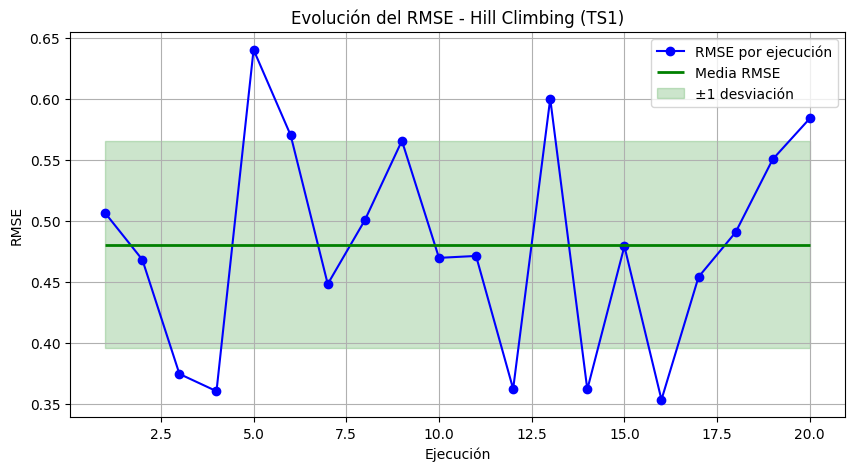

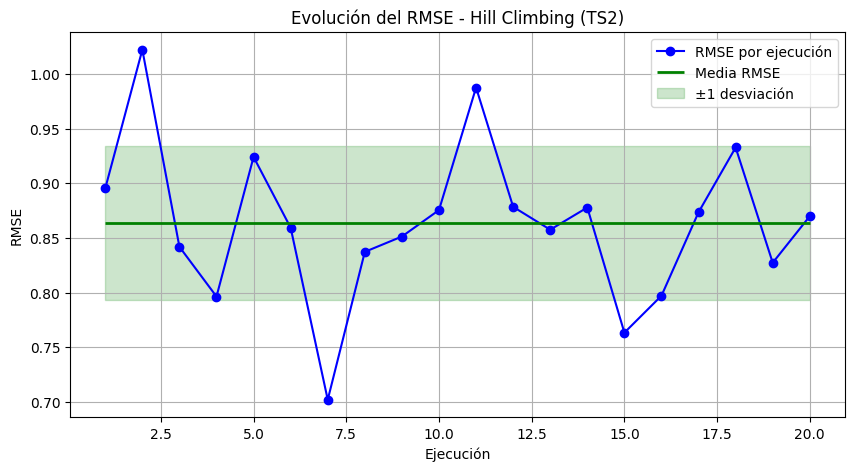

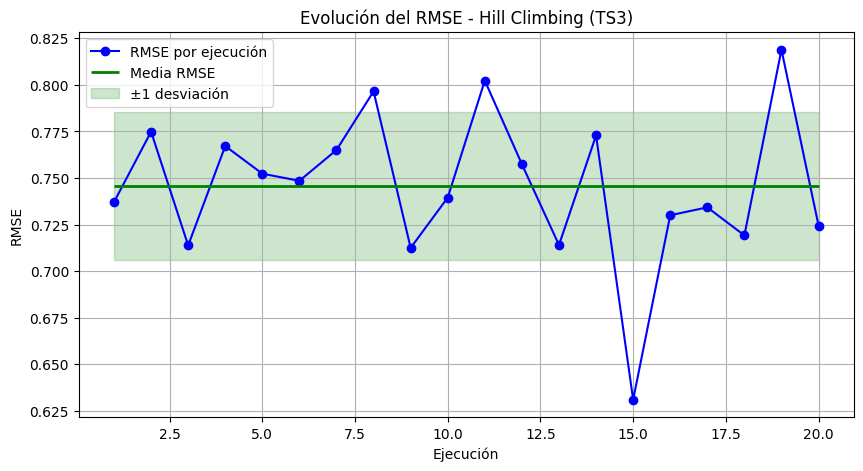

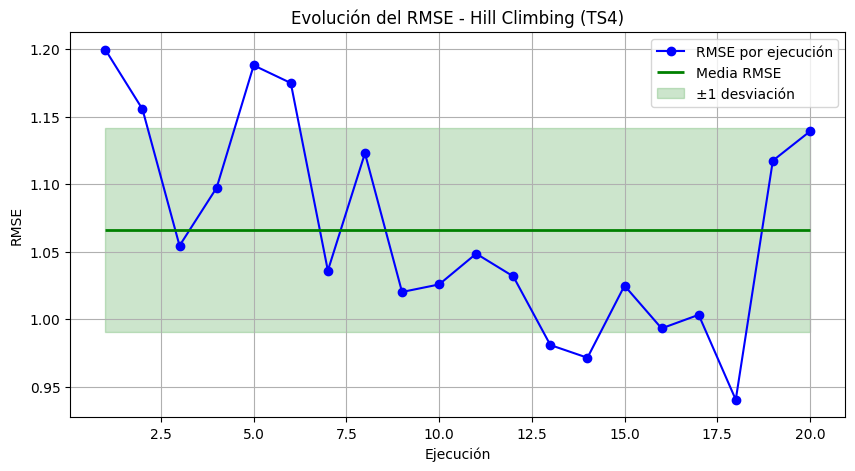

In [16]:
plot_HC_RMSE(series, resultados_HC)

### 9.2 Representación gráfica de la segmentación final

Además de analizar la variabilidad del RMSE entre ejecuciones, es importante visualizar la **solución final** obtenida por el algoritmo Hill Climbing para cada serie temporal.

En estas gráficas se representa:

- La **serie real** (en azul).  
- La **serie estimada** a partir de los segmentos óptimos encontrados por HC (en rojo).  
- Las **líneas verticales** que indican los puntos de corte seleccionados por el algoritmo.

A diferencia de Random Search, Hill Climbing no explora el espacio de soluciones de forma aleatoria, sino que realiza una búsqueda local guiada por mejoras sucesivas. Por ello, la segmentación final suele ser más estable y coherente, aunque puede depender de la solución inicial.

Estas visualizaciones permiten comprobar si las rectas ajustadas siguen adecuadamente la estructura de la serie y facilitan la comparación posterior con las soluciones obtenidas mediante Random Search y Simulated Annealing.


In [17]:
def plot_final_HC(series, resultados, k_values):
    for idx, serie in enumerate(series):
        best = min(resultados[idx], key=lambda x: x["rmse"])
        points = best["points"]

        coef = estimate_all_coef(serie, points)
        estimada = estimate_all_points(coef, points, len(serie))

        plt.figure(figsize=(12, 5))
        plt.plot(serie, label="Serie real", color="blue")
        plt.plot(estimada, label="Serie estimada", color="red")

        for p in points:
            plt.axvline(x=p, linestyle="--", color="black")

        plt.title(f"Solución final HC - TS{idx + 1} (k={k_values[idx]})")
        plt.xlabel("Tiempo")
        plt.ylabel("Valor")
        plt.legend()
        plt.grid(True)
        plt.savefig(f"TS{idx + 1}_sol.png", dpi=150)
        plt.show()


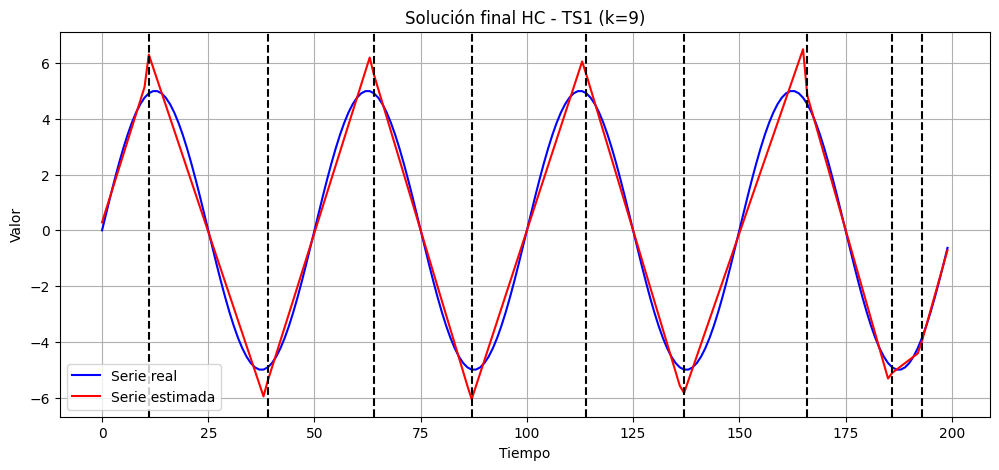

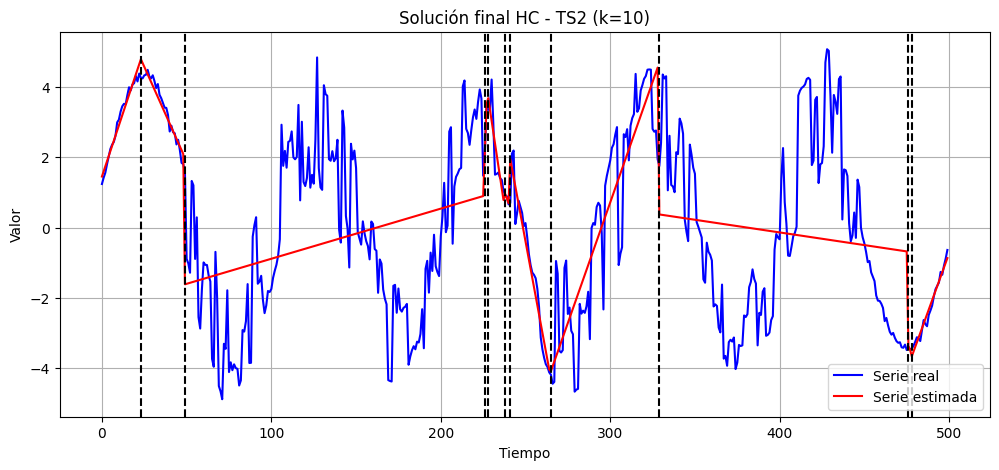

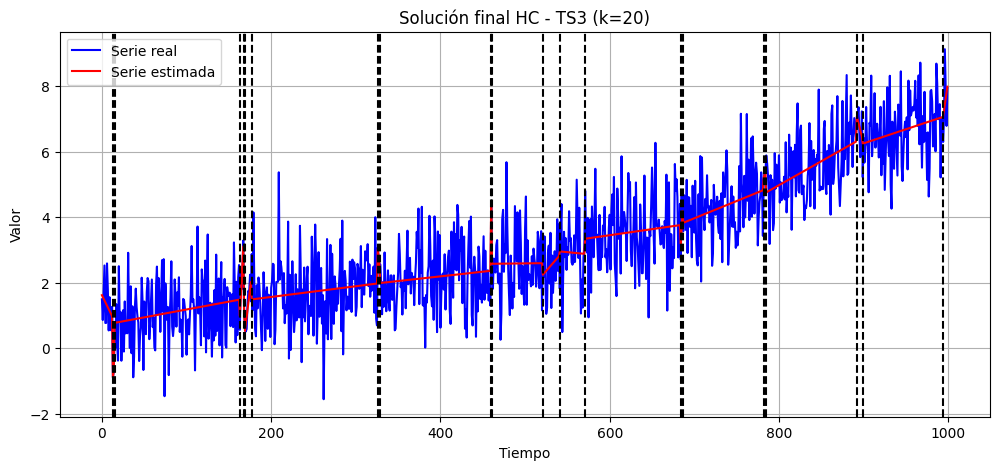

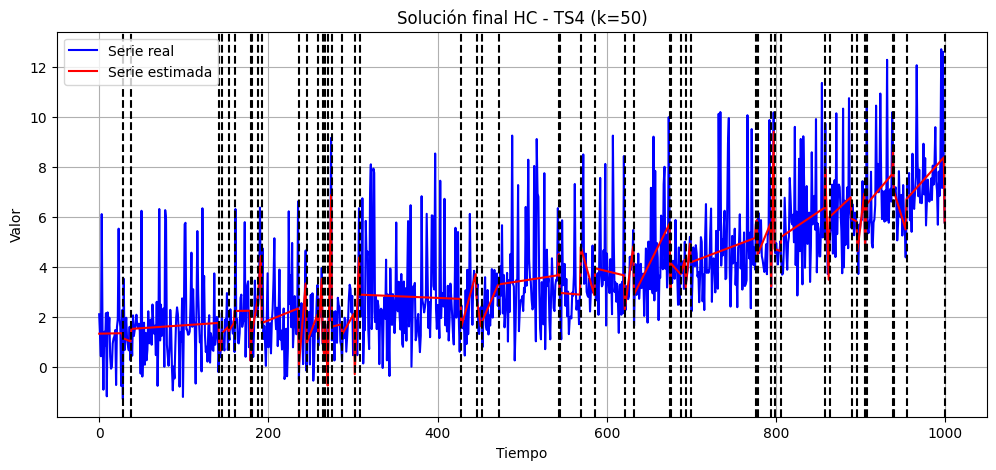

In [18]:
plot_final_HC(series, resultados_HC, k_values)

## 10. Obtención de métricas para comparar Hill Climbing

Para cada serie temporal (TS1, TS2, TS3, TS4) se calculan las métricas necesarias para comparar el rendimiento del algoritmo Hill Climbing (HC):

### Exactitud  
- El **RMSE medio final** obtenido en las 20 ejecuciones.  
- Cuanto más bajo sea el RMSE, mejor es la segmentación.

### Variabilidad  
- La **desviación típica del RMSE** entre ejecuciones.  
- Mide la estabilidad del algoritmo y su sensibilidad a la solución inicial.

### Tiempo de cómputo  
- El **tiempo medio por ejecución**.  
- Permite evaluar la eficiencia del método.

A diferencia de Random Search, Hill Climbing no depende del número de iteraciones, sino del proceso de mejora local. Por ello, las métricas se calculan directamente a partir de las 20 ejecuciones independientes.


### 10.1. EXTRAER EXACTITUD (RMSE final)

En esta sección se calcula el **RMSE medio final** obtenido por Hill Climbing en cada serie temporal.  
Este valor resume la calidad de las segmentaciones encontradas por el algoritmo.


In [19]:
def exactitud_HC(resultados_HC):
    rmse_medios = [
        pd.Series([rep["rmse"] for rep in resultados_HC[i]]).mean()
        for i in range(4)
    ]
    return rmse_medios

### 10.2. EXTRAER VARIABILIDAD (desviación típica)

Aquí se calcula la **desviación típica del RMSE** entre las 20 ejecuciones.  
Una desviación baja indica que Hill Climbing es estable y poco sensible a la solución inicial.  
Una desviación alta indica que puede caer en óptimos locales muy distintos.


In [20]:
def variabilidad_HC(resultados_HC):
    rmse_desv = [
        pd.Series([rep["rmse"] for rep in resultados_HC[i]]).std()
        for i in range(4)
    ]
    return rmse_desv

### 9.3. EXTRAER TIEMPO DE CÓMPUTO

En esta sección se calcula el **tiempo medio de ejecución** de Hill Climbing para cada serie.  
Este valor permite comparar la eficiencia del algoritmo frente a RS y SA.


In [21]:
def tiempo_HC(resultados_HC):
    tiempos_medios = [
        pd.Series([rep["tiempo"] for rep in resultados_HC[i]]).mean()
        for i in range(4)
    ]
    return tiempos_medios


### 9.4. CALCULAR MÉTRICAS

Finalmente, se construye una tabla que resume:

- RMSE medio  
- Desviación típica  
- Tiempo medio de ejecución  

para cada una de las cuatro series temporales.

Esta tabla será utilizada posteriormente en la memoria para comparar formalmente los tres algoritmos:  
Random Search (RS), Hill Climbing (HC) y Simulated Annealing (SA).

In [22]:
# Calcular métricas
rmse_medios = exactitud_HC(resultados_HC)
rmse_desv = variabilidad_HC(resultados_HC)
tiempos_medios = tiempo_HC(resultados_HC)

# Crear tabla
tabla = pd.DataFrame(
    {
        "Serie": ["TS1 (k=9)", "TS2 (k=10)", "TS3 (k=20)", "TS4 (k=50)"],
        "RMSE medio": rmse_medios,
        "Desviación típica": rmse_desv,
        "Tiempo medio (s)": tiempos_medios,
    }
)

# Formatear tabla
tabla_formateada = tabla.copy()
tabla_formateada["RMSE medio"] = tabla_formateada["RMSE medio"].map("{:.6f}".format)
tabla_formateada["Desviación típica"] = tabla_formateada["Desviación típica"].map("{:.6f}".format)
tabla_formateada["Tiempo medio (s)"] = tabla_formateada["Tiempo medio (s)"].map("{:.6f}".format)

print(
    tabulate(tabla_formateada, headers="keys", tablefmt="fancy_grid", showindex=False)
)

╒════════════╤══════════════╤═════════════════════╤════════════════════╕
│ Serie      │   RMSE medio │   Desviación típica │   Tiempo medio (s) │
╞════════════╪══════════════╪═════════════════════╪════════════════════╡
│ TS1 (k=9)  │     0.480343 │            0.086974 │           0.22492  │
├────────────┼──────────────┼─────────────────────┼────────────────────┤
│ TS2 (k=10) │     0.863474 │            0.071951 │           0.166107 │
├────────────┼──────────────┼─────────────────────┼────────────────────┤
│ TS3 (k=20) │     0.745579 │            0.040853 │           0.641941 │
├────────────┼──────────────┼─────────────────────┼────────────────────┤
│ TS4 (k=50) │     1.06614  │            0.077462 │           2.22783  │
╘════════════╧══════════════╧═════════════════════╧════════════════════╛
